# LENS-XAI Knowledge Distillation Demonstration (Multi-Dataset)

This interactive notebook demonstrates the **Phase 1 and Phase 2** implementation of the LENS-XAI Deep Learning project.

Unlike the fast 1-epoch demo, this notebook iterates through the full **20-epoch training cycle** across the **4 benchmark datasets** (NSL-KDD, Edge-IIoTset, CTU-13, UKM-IDS20) evaluating the distillation compression and accuracy.


In [1]:
import torch
import numpy as np
import time
import sys
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import clear_output

# Ensure local src modules can be imported
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.models.networks import TeacherModel, StudentModel
from src.models.train import load_data, kd_loss_function

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")

Using compute device: cpu


### Define Core Distillation Routine
This function loads the requested dataset, instantiates the heavy Teacher and edge Student models, and trains them sequentially for the set number of epochs.

In [2]:
def train_and_plot(dataset_name, epochs=20):
    print(f"\n{'='*60}")
    print(f" RUNNING LENS-XAI DISTILLATION ON: {dataset_name.upper()}")
    print(f"{'='*60}")
    
    # 1. Load Data
    try:
        train_loader, test_loader, input_dim, num_classes = load_data(dataset_name, batch_size=512)
    except FileNotFoundError:
        print(f"⚠️ {dataset_name} has not been preprocessed. Skipping.")
        return
        
    print(f"Input Features: {input_dim} | Classes: {num_classes} | Train Samples: {len(train_loader.dataset):,} | Test Samples: {len(test_loader.dataset):,}")
    
    # 2. Init Models
    teacher = TeacherModel(input_dim=input_dim, num_classes=num_classes).to(device)
    student = StudentModel(input_dim=input_dim, num_classes=num_classes).to(device)
    
    t_params = sum(p.numel() for p in teacher.parameters())
    s_params = sum(p.numel() for p in student.parameters())
    print(f"\nTeacher Parameters (H-VAE): {t_params:,}")
    print(f"Student Parameters (Edge MLP): {s_params:,}")
    print(f"Compression Achieved: {(1 - (s_params/t_params))*100:.2f}%\n")
    
    teacher.train()
    student.train()
    optimizer_t = torch.optim.Adam(teacher.parameters(), lr=0.001)
    optimizer_s = torch.optim.Adam(student.parameters(), lr=0.001)
    
    teacher_losses = []
    student_losses = []
    
    # 3. Training Loop
    start_time = time.time()
    for epoch in range(epochs):
        epoch_t_loss = 0
        epoch_s_loss = 0
        
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            # --- Train Teacher ---
            optimizer_t.zero_grad()
            t_logits = teacher(data)[0]
            t_loss = torch.nn.functional.cross_entropy(t_logits, target)
            t_loss.backward()
            optimizer_t.step()
            epoch_t_loss += t_loss.item()
            
            # --- Train Student (KD) ---
            optimizer_s.zero_grad()
            s_logits = student(data)
            with torch.no_grad():
                t_logits_soft = teacher(data)[0]
                
            s_loss = kd_loss_function(s_logits, t_logits_soft, target, alpha=0.5, temperature=3.0)
            s_loss.backward()
            optimizer_s.step()
            epoch_s_loss += s_loss.item()
            
        teacher_losses.append(epoch_t_loss / len(train_loader))
        student_losses.append(epoch_s_loss / len(train_loader))
        
        # Status Update Every 5 Epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Teacher Loss: {teacher_losses[-1]:.4f} | Student Loss: {student_losses[-1]:.4f}")
            
    print(f"\nTraining Time ({epochs} Epochs): {time.time() - start_time:.2f} seconds")
    
    # 4. Evaluation on 90% Test Set
    teacher.eval()
    student.eval()
    t_correct = 0
    s_correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            
            t_logits = teacher(data)[0]
            s_logits = student(data)
            
            t_correct += t_logits.max(1)[1].eq(target).sum().item()
            s_correct += s_logits.max(1)[1].eq(target).sum().item()
            total += target.size(0)
                
    t_acc = 100. * t_correct / total
    s_acc = 100. * s_correct / total
    print(f"\n[EVALUATION] Teacher Acc: {t_acc:.2f}% | Student Acc: {s_acc:.2f}%")
    
    # 5. Plot Convergence Curve
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, epochs+1), teacher_losses, label='Teacher (CrossEntropy Loss)', marker='o')
    plt.plot(range(1, epochs+1), student_losses, label='Student (Knowledge Distillation Loss)', marker='s')
    plt.title(f'LENS-XAI Training Convergence ({dataset_name.upper()})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
plt.show()

### Run the Distillation Pipeline Across All 4 Datasets


 RUNNING LENS-XAI DISTILLATION ON: NSL-KDD
Input Features: 122 | Classes: 2 | Train Samples: 14,851 | Test Samples: 133,666

Teacher Parameters (H-VAE): 76,407
Student Parameters (Edge MLP): 11,474
Compression Achieved: 84.98%

Epoch [5/20] | Teacher Loss: 0.0627 | Student Loss: 0.2314
Epoch [10/20] | Teacher Loss: 0.0462 | Student Loss: 0.2290
Epoch [15/20] | Teacher Loss: 0.0527 | Student Loss: 0.2163
Epoch [20/20] | Teacher Loss: 0.0392 | Student Loss: 0.1919

Training Time (20 Epochs): 7.61 seconds

[EVALUATION] Teacher Acc: 98.37% | Student Acc: 96.62%

 RUNNING LENS-XAI DISTILLATION ON: UKM-IDS20
Input Features: 49 | Classes: 2 | Train Samples: 1,288 | Test Samples: 11,599

Teacher Parameters (H-VAE): 45,004
Student Parameters (Edge MLP): 2,903
Compression Achieved: 93.55%

Epoch [5/20] | Teacher Loss: 0.5026 | Student Loss: 0.3331
Epoch [10/20] | Teacher Loss: 0.0531 | Student Loss: 1.1315
Epoch [15/20] | Teacher Loss: 0.0019 | Student Loss: 2.1233
Epoch [20/20] | Teacher Loss:

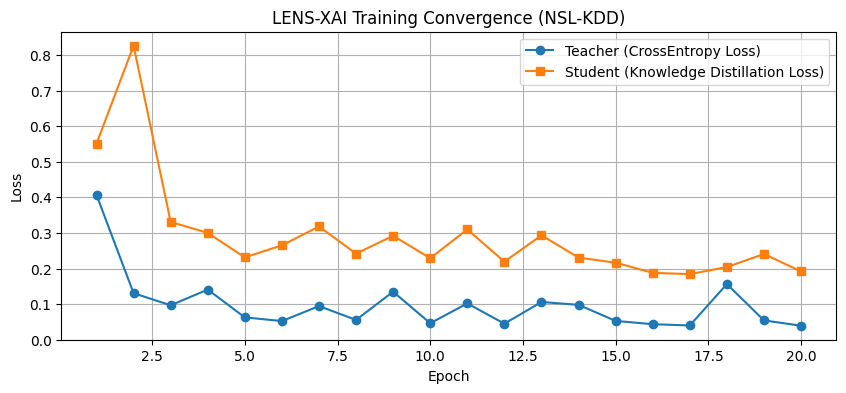

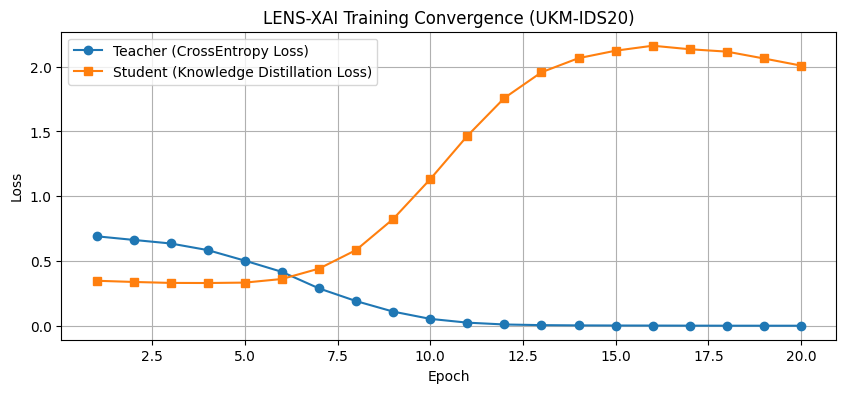

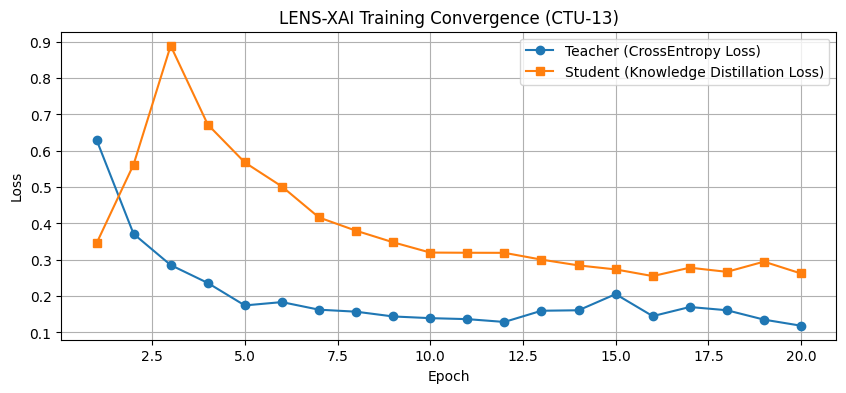

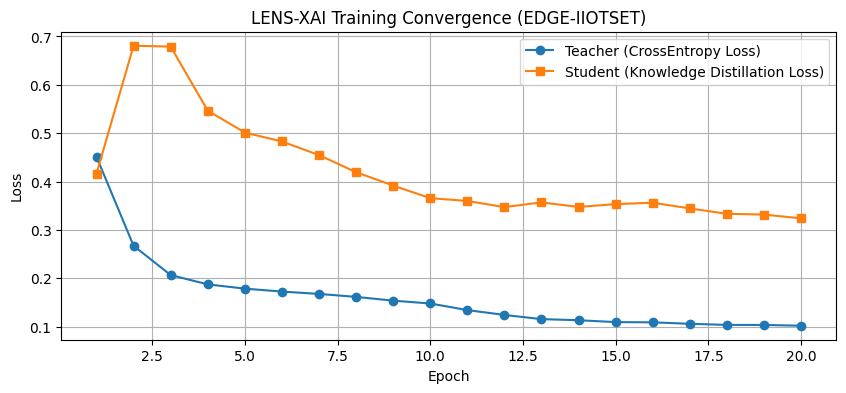

In [3]:
datasets = ["nsl-kdd", "ukm-ids20", "ctu-13", "edge-iiotset"]
for ds in datasets:
    train_and_plot(ds, epochs=20)